# EEG checking the data the data

In [1]:
!bluetoothctl devices | grep -i muse

Device 00:55:DA:BB:5E:F0 MuseS-5EF0


### Important
Do this in terminal it will be active through the whole proces of gaining the data

In [ ]:
#!muselsl stream --address 0:55:DA:BB:5D:FA  # after adress you paste the adress you get from previous code ater the "Device"

### Recording the data

In [3]:
!muselsl record --duration 10   #Here duration is for 4 minutes but you can change it

Looking for a EEG stream...
2026-04-01 15:04:41.401 (   0.799s) [        F978E600]      netinterfaces.cpp:89    INFO| netif 'lo' (status: 1, multicast: 0, broadcast: 0)
2026-04-01 15:04:41.401 (   0.799s) [        F978E600]      netinterfaces.cpp:89    INFO| netif 'wlp0s20f3' (status: 1, multicast: 4096, broadcast: 2)
2026-04-01 15:04:41.401 (   0.799s) [        F978E600]      netinterfaces.cpp:89    INFO| netif 'lo' (status: 1, multicast: 0, broadcast: 0)
2026-04-01 15:04:41.401 (   0.799s) [        F978E600]      netinterfaces.cpp:89    INFO| netif 'wlp0s20f3' (status: 1, multicast: 4096, broadcast: 2)
2026-04-01 15:04:41.401 (   0.799s) [        F978E600]      netinterfaces.cpp:102   INFO| 	IPv4 addr: c0a8163f
2026-04-01 15:04:41.401 (   0.799s) [        F978E600]      netinterfaces.cpp:89    INFO| netif 'lo' (status: 1, multicast: 0, broadcast: 0)
2026-04-01 15:04:41.401 (   0.799s) [        F978E600]      netinterfaces.cpp:89    INFO| netif 'wlp0s20f3' (status: 1, multicast: 4096,

# Preprocessing
## 1. Importing libraries

In [5]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone

## 2. Load raw data

In [6]:
path = "/home/zofia/muse/EEG_recording_2026-04-01-13.04.41.csv"
df = pd.read_csv(path)
df.head()

,timestamps,TP9,AF7,AF8,TP10,Right AUX
0,1.775049e+09,-45.410,-52.246,-47.852,-43.945,0.0
1,1.775049e+09,-33.691,-36.621,-44.922,-38.574,0.0
2,1.775049e+09,-31.738,-35.156,-43.457,-37.598,0.0
3,1.775049e+09,-31.250,-38.574,-42.969,-44.434,0.0
4,1.775049e+09,-32.227,-22.461,-44.434,-40.039,0.0


In [7]:
ch_names = ['TP9', 'AF7', 'AF8', 'TP10'] # Channel names

In [8]:
data_values = df[ch_names].values.T * 1e-6  # Convert from microvolts to volts

## 3. Metadata

In [9]:
sfreq = 256
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')


In [10]:
# Sex: 0 = Unknown, 1 = Male, 2 = Female
# Hand: 0 = Unknown, 1 = Right, 2 = Left, 3 = Both

In [11]:
my_date = datetime(2026, 3, 31, 12, 44, 4, tzinfo=timezone.utc)
info.set_meas_date(my_date)

<Info | 7 non-empty values
 bads: []
 ch_names: TP9, AF7, AF8, TP10
 chs: 4 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2026-03-31 12:44:04 UTC
 nchan: 4
 projs: []
 sfreq: 256.0 Hz
>

## 4. Create raw object

In [12]:
raw = mne.io.RawArray(data_values, info)

Creating RawArray with float64 data, n_channels=4, n_times=1296
    Range : 0 ... 1295 =      0.000 ...     5.059 secs
Ready.


In [13]:
# Apply the standard 10-20 montage so channel positions are known
# (needed for PSD and topomap visualisations)
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

<RawArray | 4 x 1296 (5.1 s), ~52 KiB, data loaded>

In [14]:
#raw.save("AP_raw_open_eyes.fif", overwrite=True)
print(raw)
print(raw.info)

<RawArray | 4 x 1296 (5.1 s), ~52 KiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: TP9, AF7, AF8, TP10
 chs: 4 EEG
 custom_ref_applied: False
 dig: 7 items (3 Cardinal, 4 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2026-03-31 12:44:04 UTC
 nchan: 4
 projs: []
 sfreq: 256.0 Hz
>


## 5. Visual Quality Check

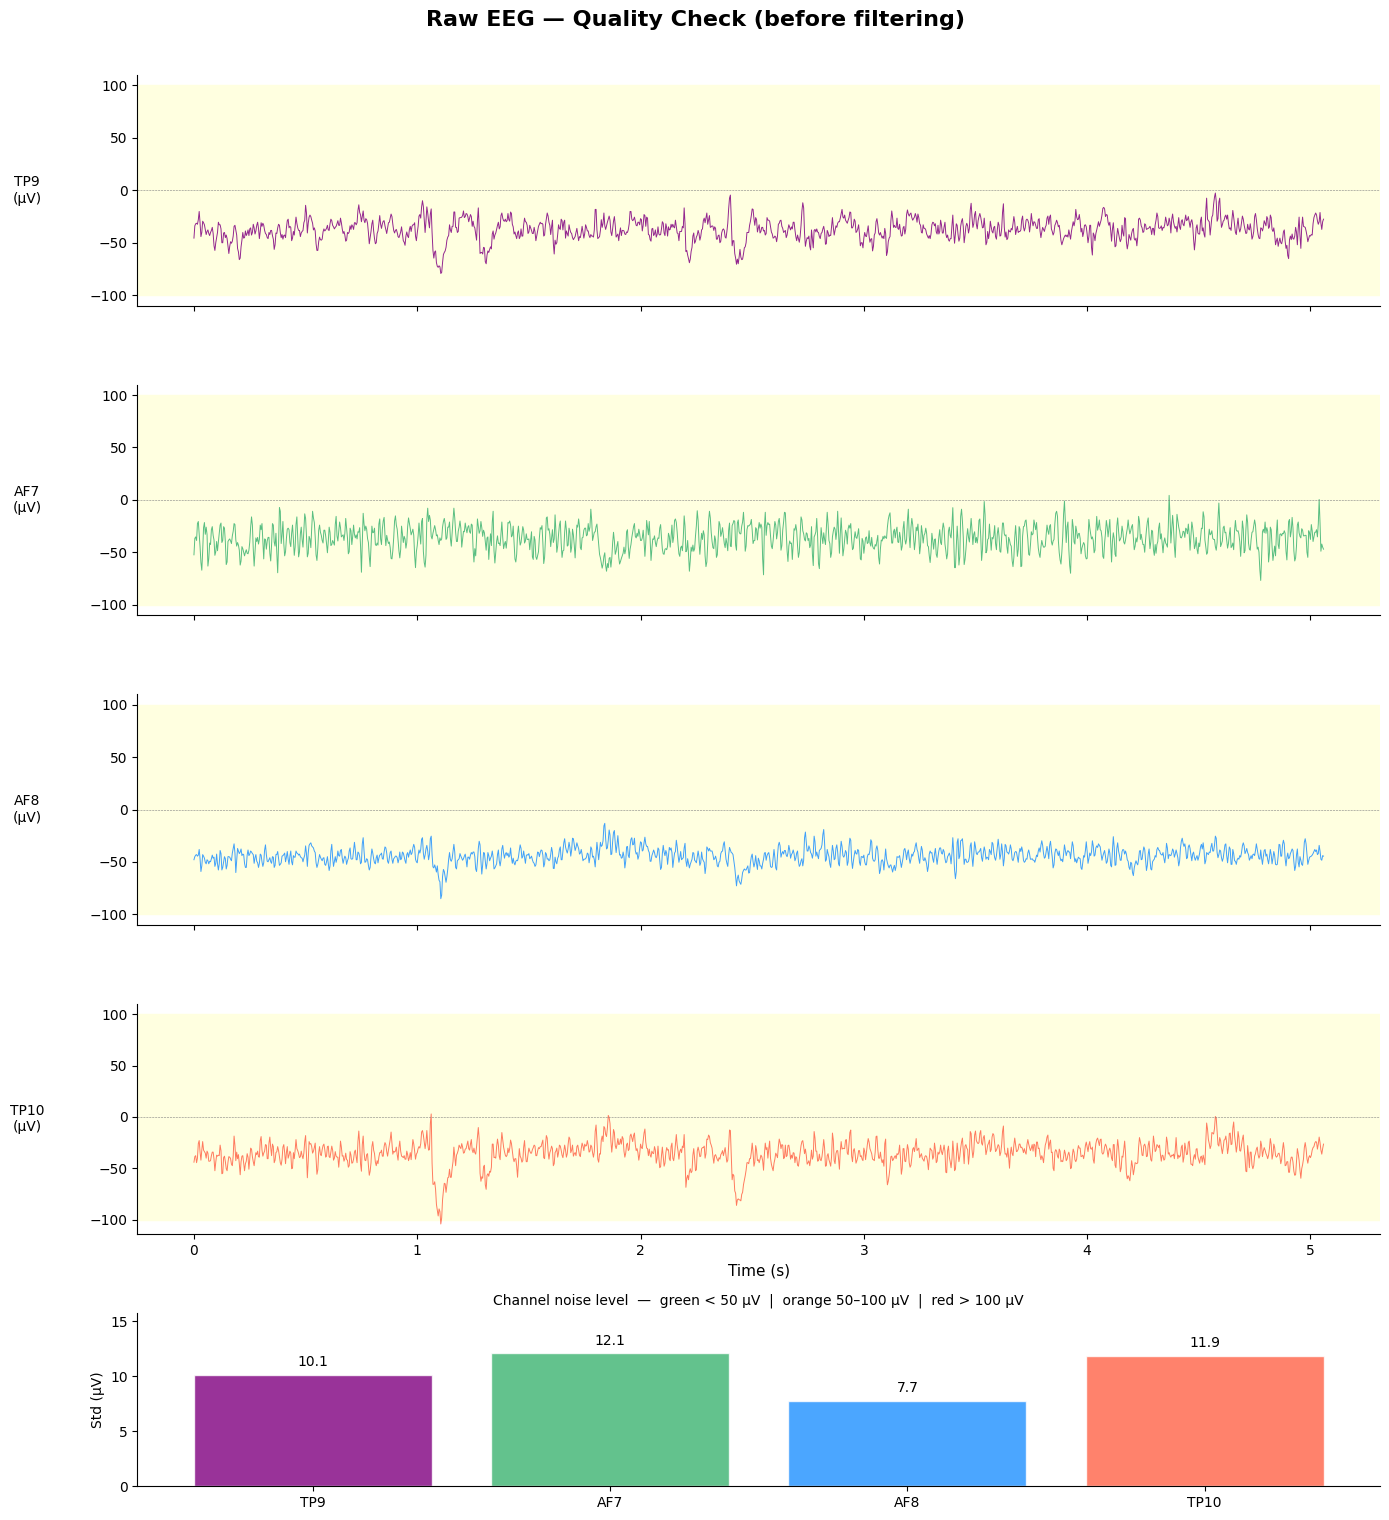

✓ Quality check plot saved to eeg_quality_check.png

Channel statistics (first segment):
  Channel     Min (µV)    Max (µV)    Std (µV)  Status
  -------------------------------------------------------
  TP9            -79.1        -2.4        10.1  ✓ ok
  AF7            -76.7         4.4        12.1  ✓ ok
  AF8            -85.0       -13.2         7.7  ✓ ok
  TP10          -104.0         2.9        11.9  ✓ ok


In [15]:
def plot_eeg_overview(raw, title="Raw EEG Overview", segment_duration=10):
    """
    Static multi-panel EEG quality check — works in any environment
    (no interactive MNE backend required).

    Panels (top to bottom):
      1. Raw traces for each channel, stacked with a shared time axis.
         Each channel gets its own y-axis so amplitude scale is clear.
      2. Per-channel signal statistics (min / max / std) printed as a
         colour-coded bar chart so you can instantly spot outliers.

    Parameters
    ----------
    raw               : mne.io.Raw   — the raw object to inspect
    title             : str          — figure suptitle
    segment_duration  : float        — how many seconds to show (default 10)
    """
    sfreq        = int(raw.info['sfreq'])
    ch_names     = raw.ch_names
    n_ch         = len(ch_names)
    colors       = ['purple', 'mediumseagreen', 'dodgerblue', 'tomato']

    n_samples = min(int(segment_duration * sfreq), raw.n_times)
    data, times = raw[:, :n_samples]          # shape: (n_ch, n_samples)
    data_uv = data * 1e6                      # V → µV for readable numbers

    fig, axes = plt.subplots(
        n_ch + 1, 1,
        figsize=(14, 3 * n_ch + 3),
        gridspec_kw={'height_ratios': [2] * n_ch + [1.5]},
    )
    fig.suptitle(title, fontsize=16, weight='bold', y=1.01)

    for i, (ch, color) in enumerate(zip(ch_names, colors)):
        ax = axes[i]
        ax.plot(times, data_uv[i], color=color, linewidth=0.7, alpha=0.85)
        ax.set_ylabel(f"{ch}\n(µV)", fontsize=10, rotation=0,
                      labelpad=45, va='center')
        ax.spines[['top', 'right']].set_visible(False)

        ax.axhline(0, color='grey', linewidth=0.4, linestyle='--')

        ax.axhspan(-100, 100, color='lightyellow', zorder=0)

        if i < n_ch - 1:
            ax.set_xticklabels([])

    axes[n_ch - 1].set_xlabel("Time (s)", fontsize=11)

    ax_stat = axes[n_ch]
    stds    = data_uv.std(axis=1)
    bars    = ax_stat.bar(ch_names, stds, color=colors, alpha=0.8, edgecolor='white')

    for bar, std_val in zip(bars, stds):
        if std_val > 100:
            bar.set_facecolor('red')
            bar.set_alpha(0.9)
        elif std_val > 50:
            bar.set_facecolor('orange')
            bar.set_alpha(0.9)

    for bar, std_val in zip(bars, stds):
        ax_stat.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{std_val:.1f}",
            ha='center', va='bottom', fontsize=10,
        )

    ax_stat.set_ylabel("Std (µV)", fontsize=10)
    ax_stat.set_title(
        "Channel noise level  —  green < 50 µV  |  orange 50–100 µV  |  red > 100 µV",
        fontsize=10,
    )
    ax_stat.spines[['top', 'right']].set_visible(False)
    ax_stat.set_ylim(0, max(stds) * 1.3)

    plt.tight_layout()
    #plt.savefig("eeg_quality_check.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Quality check plot saved to eeg_quality_check.png")

    print("\nChannel statistics (first segment):")
    print(f"  {'Channel':<8}  {'Min (µV)':>10}  {'Max (µV)':>10}  {'Std (µV)':>10}  {'Status'}")
    print("  " + "-" * 55)
    for i, ch in enumerate(ch_names):
        mn, mx, sd = data_uv[i].min(), data_uv[i].max(), data_uv[i].std()
        status = "✓ ok" if sd < 50 else ("⚠ noisy" if sd < 100 else "✗ very noisy — consider marking as bad")
        print(f"  {ch:<8}  {mn:>10.1f}  {mx:>10.1f}  {sd:>10.1f}  {status}")

plot_eeg_overview(raw, title="Raw EEG — Quality Check (before filtering)")

In [16]:
!ls

analysis.ipynb
eeg_analysis.ipynb
eeg_check.ipynb
EEG_recording_2026-04-01-13.04.41.csv
eeg_setup.py
eeg_study
environment.yml
images
MT_open90_closed90_2026-03-17-12.07.56.csv
participants.csv
preprocess.py
README.md
records
results
stats.ipynb


In [17]:
!rm EEG_recording*.csv

In [18]:
raw = mne.io.read_raw_fif("/home/zofia/muse/eeg_study/participant_01/session_1/pre/closed_eyes/filtered/P01_S1_pre_closed_eyes_filtered_raw.fif", preload=True)

Opening raw data file /home/zofia/muse/eeg_study/participant_01/session_1/pre/closed_eyes/filtered/P01_S1_pre_closed_eyes_filtered_raw.fif...
    Range : 0 ... 29543 =      0.000 ...   115.402 secs
Ready.
Reading 0 ... 29543  =      0.000 ...   115.402 secs...


In [19]:
print(raw.info)

<Info | 12 non-empty values
 bads: []
 ch_names: TP9, AF7, AF8, TP10
 chs: 4 EEG
 custom_ref_applied: False
 dig: 7 items (3 Cardinal, 4 EEG)
 experimenter: Zofia Sikorska
 file_id: 4 items (dict)
 highpass: 0.5 Hz
 lowpass: 35.0 Hz
 meas_date: 2026-04-01 09:58:14 UTC
 meas_id: 4 items (dict)
 nchan: 4
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | id: 1, his_id: P_01, birthday: 2005-01-01, sex: 2, hand: 1>
>
